## Get and Format Data
### Only do this once (until someone changes the code)
1. Run all blocks in notebooks/bipartite_graph.ipynb
2. cd into notebooks
2. Run process_graphs.py
3. Run run_simulations.py (there are hyperparameters on the number of trajectories to simulate and expansion types)
4. Run this notebook

In [1]:
# General imports
import sys
import os

# ----File Stitching----
# If in models folder, cd back to notebooks folder
if os.path.basename(os.getcwd()) == "models":
    os.chdir('..')
# If a file is in /src/, access it by telling the system to look at that path as well as current path
sys.path.append(os.path.join(os.getcwd(), '..', 'src'))

# Import from .py files 
from training import load_and_prepare_training_data, ImitationTrainer
train_dataloader, val_dataloader, static_graph = load_and_prepare_training_data()
node_dim = static_graph['x_static'].shape[1] + 1 
_, _, _, sample_event_feat = next(iter(train_dataloader))
event_dim = sample_event_feat.shape[1]

Loading imitation data from disk...
Loading index mappings...
Splitting data with 20.0% validation ratio...
Building PyTorch Train DataLoader...
Loading static graph topology...
Aligning static user features...
Aligning event features...
Building PyTorch Validation DataLoader...
Loading static graph topology...
Aligning static user features...
Aligning event features...


## Define Model

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv 

class MultiplexSeedingModel(nn.Module):
    def __init__(self, node_dim, event_dim, edge_dim=1, hidden_dim=128):
        super().__init__()
        
        # Encoders
        self.node_encoder = nn.Linear(node_dim, hidden_dim)
        self.event_encoder = nn.Linear(event_dim, hidden_dim)
        
        # Parallel Message Passing
        self.conv1_1 = GATConv(hidden_dim, hidden_dim // 2, edge_dim=edge_dim)
        self.conv2_1 = GATConv(hidden_dim, hidden_dim // 2, edge_dim=edge_dim)
        
        self.fusion_layer = nn.Linear(hidden_dim, hidden_dim)
        
        # Final Scorer - input dim is hidden_dim * 2 due to node + event concatenation
        self.scorer = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x_batch, static_graph, event_feat_batch):
        """
        Args:
            x_batch: Tensor of shape [B, N, F+1]
            static_graph: Dict of pre-loaded, unbatched PyG topology tensors
            event_feat_batch: Tensor of shape [B, event_dim]
        """
        B, N, _ = x_batch.shape
        
        # 1. Initial Encodings
        x_encoded = F.relu(self.node_encoder(x_batch)) # [B, N, hidden_dim]
        event_encoded = F.relu(self.event_encoder(event_feat_batch)) # [B, hidden_dim]
        
        x_nodes_list = []
        
        # 2. Sequential Message Passing (Avoid OOM on large graphs)
        for b in range(B):
            x_b = x_encoded[b] # [N, hidden_dim]
            
            x_1 = F.elu(self.conv1_1(x_b, static_graph['edge_index_1'], static_graph['edge_attr_1']))
            x_2 = F.elu(self.conv2_1(x_b, static_graph['edge_index_2'], static_graph['edge_attr_2']))
            
            x_fused = torch.cat([x_1, x_2], dim=-1)
            x_nodes = F.relu(self.fusion_layer(x_fused)) # [N, hidden_dim]
            x_nodes_list.append(x_nodes)
            
        batch_x_nodes = torch.stack(x_nodes_list) # [B, N, hidden_dim]
        
        # 3. Contextualize with Event Features
        # Expand event embeddings to match node dimension: [B, hidden_dim] -> [B, N, hidden_dim]
        event_expanded = event_encoded.unsqueeze(1).expand(-1, N, -1)
        
        # Combine node representations with the target event context
        combined = torch.cat([batch_x_nodes, event_expanded], dim=-1) # [B, N, hidden_dim * 2]
        
        # 4. Score Nodes
        logits = self.scorer(combined).squeeze(-1) # [B, N]
        
        # 5. Autoregressive Masking
        # Mask out nodes that are already seeded (tracked in channel 0 of x_batch)
        seed_mask = x_batch[:, :, 0].bool()
        logits = logits.masked_fill(seed_mask, float('-1e9'))
        
        # Return raw logits to align with BCEWithLogitsLoss
        return logits

## Run Training Script


Initializing model with Node Dim: 9, Event Dim: 64

Starting Training...
Starting training on cpu...
Epoch 1/10 | Train BCE: 0.7757 | Val BCE: 0.9787
Epoch 2/10 | Train BCE: 0.8800 | Val BCE: 1.3093
Epoch 3/10 | Train BCE: 0.5566 | Val BCE: 3.2824
Epoch 4/10 | Train BCE: 2.7650 | Val BCE: 1.6193
Epoch 5/10 | Train BCE: 0.7506 | Val BCE: 1.3084
Epoch 6/10 | Train BCE: 0.7605 | Val BCE: 1.1788
Epoch 7/10 | Train BCE: 0.9657 | Val BCE: 1.1297
Epoch 8/10 | Train BCE: 1.0898 | Val BCE: 1.1552
Epoch 9/10 | Train BCE: 1.1453 | Val BCE: 1.2228
Epoch 10/10 | Train BCE: 1.1476 | Val BCE: 1.3075
Training complete.
Loss curve saved to loss_curve.png
Loss curve saved to loss_curve.png


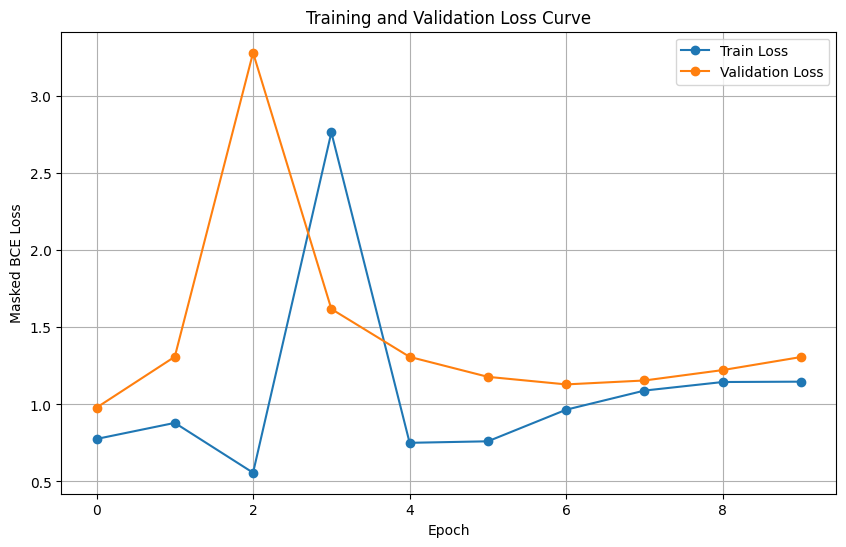

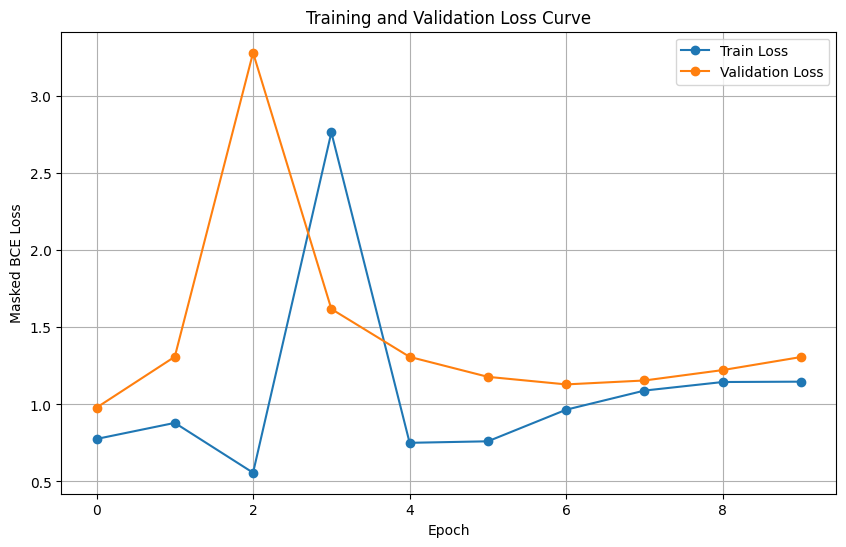

In [3]:
    
print(f"\nInitializing model with Node Dim: {node_dim}, Event Dim: {event_dim}")

model = MultiplexSeedingModel(
    node_dim=node_dim,
    event_dim=event_dim,
    hidden_dim=128
)

config = {
    'lr': 1e-3,
    'epochs': 10,
    'project_name': 'meetup-contagion-seeding',
    'run_name': 'mcmc-vectorized-run'
}

trainer = ImitationTrainer(
    model=model,
    train_dataloader=train_dataloader,
    val_dataloader=val_dataloader,
    static_graph=static_graph,
    config=config,
    use_wandb=False # Switch to False if you dont have wandb setup
)
print("\nStarting Training...")
trainer.train()
trainer.plot_losses()